# Assignment 3: Linear Models

In [43]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
    - A model is linear if the data can be represented with a slope in a strong positive correlation. If plotted on a graph, it typically looks like a straight line with a constant slope/rate of change. 
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
   - The coefficient/intercept is the predicted value for the group that the dummy variable stands for. 
3. Can linear regression be used for classification? Explain why, or why not.
   - Linear regression can not be used for classification very well because it is meant to represent a relationship between one specific independent and dependent variable. Linear regression is made for weights and numeric values, while categorical values are better for classification.
4. What are signs that your linear model is over-fitting?
   - You can tell if a linear model is over-fitting if there is not much flexibility because it is trained too well on the training data and does not adapt well the to testing data.
5. Clearly explain multi-colinearity using the two-stage least squares technique.
   - Multi-colinearity is when multiple variables are very highly correlated, so the point where you can not always tell which is which, and the two-stage least squares technique allows us to isolate one of the variables that is problematic to see which is the cause.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis? 
   - hjh
7. What is the interpretation of the slope coefficient in a linear regression?
   - The slope coefficient of a linear regression indicated the correlation between the variables x and y. If positive, there is a positive correlation between the two variables. If negative, there is a negative correlation.
8. Compare the train/test split and $k$-fold cross validation.
   - The train/test split sets aside part of the data to try to train the model that you will then use the on your testing data, while the k-fold cross validation puts the data into k number of folds and 
9.  How is the $k$ in $k$-fold cross validation typically selected?
    - k is usually a value that splits the data into equal parts while maintaining a balance of variance and bias. There are standard values people usually find to fit well, but sometimes k values must be tested to see if they fit it well. 

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [44]:
q1 = pd.read_csv("./data/Q1_clean.csv")
q1 = q1.rename(columns = {'Review Scores Rating': 'score', "Price": "price", "Neighbourhood ": "borough"})
q1['log_price'] = np.log(q1['price'])
q1.head()

,price,score,borough,Property Type,Room Type,log_price
0,549,96.0,Manhattan,Apartment,Private room,6.308098
1,149,100.0,Brooklyn,Apartment,Entire home/apt,5.003946
2,250,100.0,Manhattan,Apartment,Entire home/apt,5.521461
3,90,94.0,Brooklyn,Apartment,Private room,4.499810
4,270,90.0,Manhattan,Apartment,Entire home/apt,5.598422


In [45]:
# part 1
avg_q1 = q1.groupby('borough')[["price", "score"]].mean()
avg_q1

,price,score
borough,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


Manhattan is the most expensive borough on average.

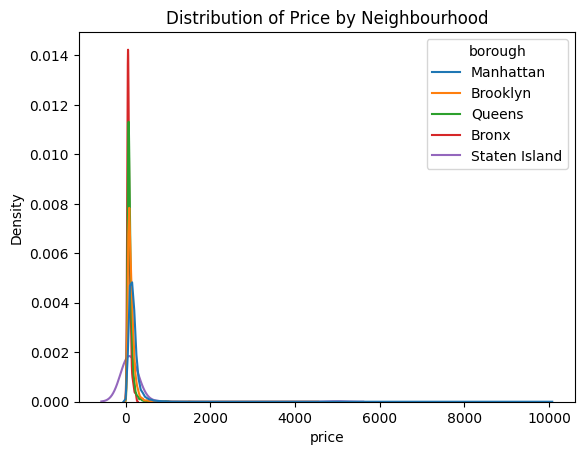

In [46]:
kde_1 = sns.kdeplot(q1, x='price', hue='borough', common_norm = False)
plt.title("Distribution of Price by Neighbourhood")
plt.show()

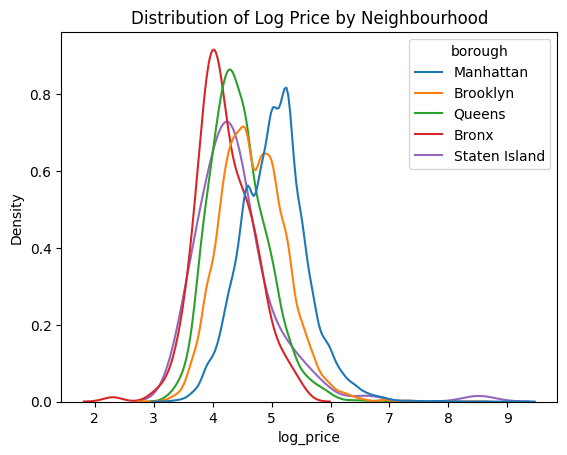

In [47]:
kde_2 = sns.kdeplot(q1, x='log_price', hue= 'borough', common_norm=False)
plt.title("Distribution of Log Price by Neighbourhood")
plt.show()

In [48]:
# part 2

x = pd.get_dummies(q1['borough'], dtype='int', drop_first=True)
y = q1['price']

model = LinearRegression().fit(x, y)

print("Intercept:", model.intercept_)
pd.DataFrame({'variable': model.feature_names_in_, 'coefficient': model.coef_})

Intercept: 75.27649769584602


,variable,coefficient
0,Brooklyn,52.470881
1,Manhattan,108.387789
2,Queens,21.580735
3,Staten Island,70.890169


The conditional group means 

In [49]:
# part 3 

x = q1[['score']]
y = q1['price']

model = LinearRegression(fit_intercept=True)
model.fit(x,y)

print("Intercept:", model.intercept_)
print('Score slope:', model.coef_[0])

Intercept: 60.87839065712386
Score slope: 1.020826602267473


The intercept represents the estimated price, and the slope coefficient represents how much the price increases as the score increases.

In [50]:
# part 4

x_cat = pd.get_dummies(q1['borough'], drop_first=True)
x_num = q1[['score']]
x = pd.concat([x_num, x_cat], axis=1)

y = q1['price']

model = LinearRegression(fit_intercept=True)
model.fit(x,y)

print("Intercept:", model.intercept_)
print('Score slope:', model.coef_[0])

Intercept: -23.81256101167307
Score slope: 1.0811164834598521


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [51]:
# part 1

cars = pd.read_csv('./data/cars_hw.csv')
cars = cars.rename(columns = {'Price':'price', 'Make_Year':'year', 'Body_Type':'body', 'Seating_Capacity':'seatcap'})
cars.head()

,Unnamed: 0,Make,year,Color,body,Mileage_Run,No_of_Owners,seatcap,Fuel_Type,Transmission,Transmission_Type,price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [52]:
cars['price'].describe()

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: price, dtype: float64

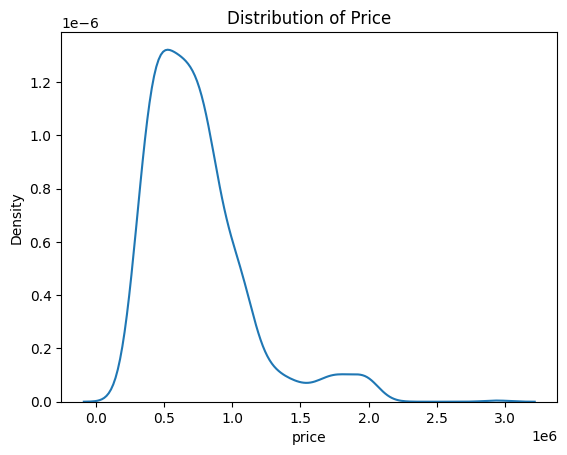

In [53]:
kde_price = sns.kdeplot(cars, x='price', common_norm=False)
plt.title('Distribution of Price')
plt.show()

In [54]:
price_sum = cars.groupby('body')['price'].describe()
print(price_sum)

           count          mean            std       min       25%        50%  \
body                                                                           
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
body                             
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


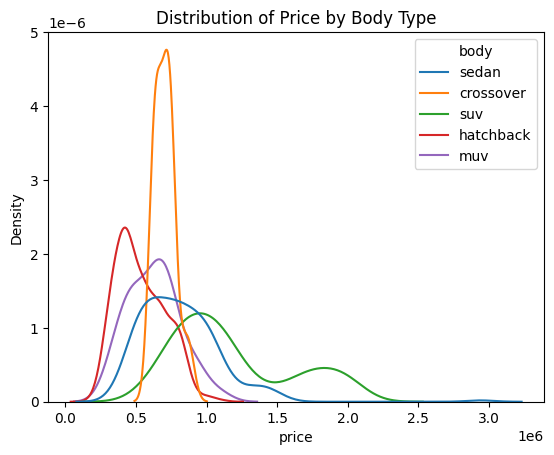

In [55]:
kde_group = sns.kdeplot(cars, x='price', hue='body', common_norm=False)
plt.title("Distribution of Price by Body Type")
plt.show()

Sedans are the most expensive car types and suvs have the most variance.

In [57]:
# part 2

x = cars[['seatcap']]
y = cars['price']

model = LinearRegression(fit_intercept=True)
model.fit(x,y)

print("Intercept:", model.intercept_)
print('Slope Coefficient:', model.coef_[0])

Intercept: 439032.0141018268
Slope Coefficient: 59267.9980367217


In [59]:
x = pd.get_dummies(cars['seatcap'], drop_first=True)
y = cars['price']

model = LinearRegression(fit_intercept=True)
model.fit(x,y)

print("Intercept:", model.intercept_)
print('Slope Coefficient:')
print(pd.Series(model.coef_))

Intercept: 188000.00000000396
Slope Coefficient:
0    5.464839e+05
1    1.456000e+06
2    7.359487e+05
3    2.718000e+05
dtype: float64


In [60]:
# part 3

cars['age'] = 2026 - cars['year']
cars.head()

,Unnamed: 0,Make,year,Color,body,Mileage_Run,No_of_Owners,seatcap,Fuel_Type,Transmission,Transmission_Type,price,age
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000,9
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000,10
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000,7
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000,9
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000,9


In [ ]:
from sklearn.model_selection import cross_val_score

x = df[['age']]
y = cars['price']

kf = KF


**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [61]:
heart = pd.read_csv('./data/heart_hw.csv')
heart.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


In [66]:
heart['transplant'].value_counts()

transplant
treatment    69
control      34
Name: count, dtype: int64